# Introduction to `lamatrix`: Fitting with priors

`lamatrix` has the capability to add Gaussian priors to your fit. Priors can help constrain your fit. Here we will go through an example of how to include priors. 

In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

First, we'll create some noisy data which has a linear trend in it

In [2]:
x = np.arange(-1, 1, 0.01)
y = x * 2.3459 + 1.435 + np.random.normal(0, 5, size=len(x))
ye = np.ones(len(x)) * 5

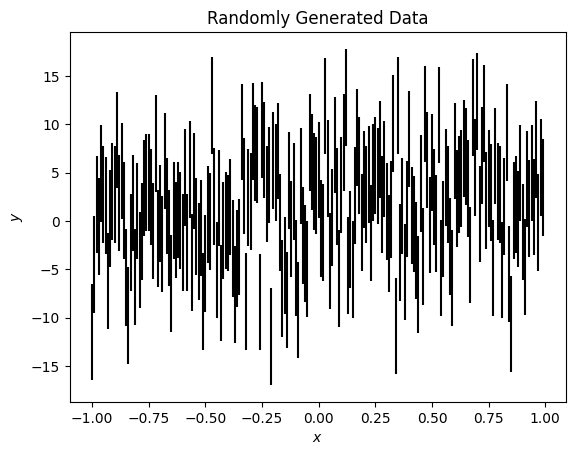

In [3]:
fig, ax = plt.subplots()
ax.errorbar(x, y, ye, ls='', c='k')
ax.set(xlabel='$x$', ylabel='$y$', title='Randomly Generated Data');

We see if we fit this data using our polynomial model we do get a fit, but the errors on the fit are large because of our large measurement errors.

In [4]:
from lamatrix import Polynomial, Constant, Distribution

In [5]:
model = Polynomial('x', order=1) + Constant()
model.fit(x=x, data=y, errors=ye)

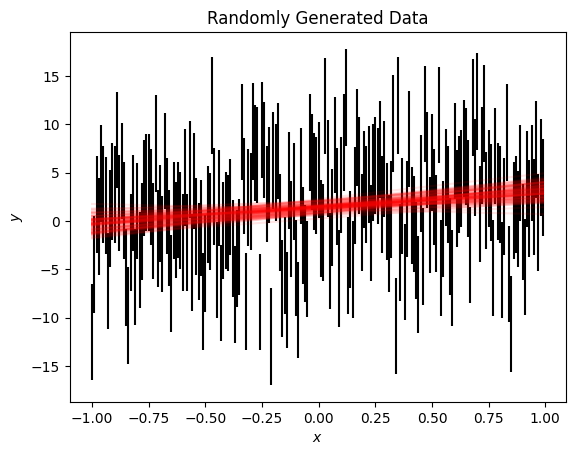

In [6]:
fig, ax = plt.subplots()
ax.errorbar(x, y, ye, ls='', c='k')
ax.plot(x, np.asarray([model.sample(x=x) for count in range(100)]).T, c='r', alpha=0.1);
ax.set(xlabel='$x$', ylabel='$y$', title='Randomly Generated Data');

We might have a case where we have a strong prior on this trend. We can include priors on each component of our model. Priors are distributions and so we define them as (mean, standard deviation). The `Distribution` class in `lamatrix` helps us work with these distributions. You can either pass a `Distribution` object or a tuple, and `lamatrix` will convert it to one. 

Below I have put tight priors on the linear trend and on the constant. 

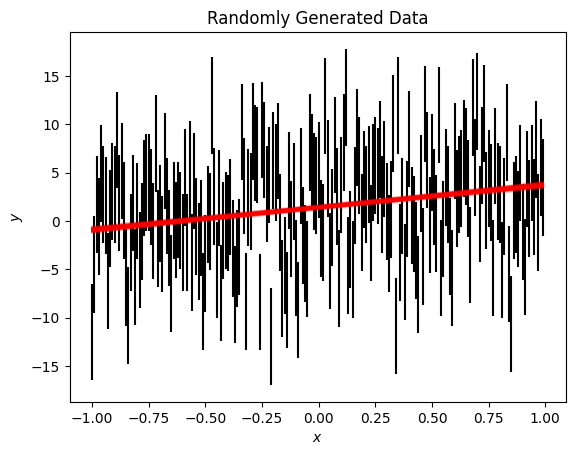

In [7]:
model = Polynomial('x', order=1, priors=[(2.3459, 0.1)]) + Constant(priors=[(1.435, 0.1)])
model.fit(x=x, data=y, errors=ye)

fig, ax = plt.subplots()
ax.errorbar(x, y, ye, ls='', c='k')
ax.plot(x, np.asarray([model.sample(x=x) for count in range(100)]).T, c='r', alpha=0.1);
ax.set(xlabel='$x$', ylabel='$y$', title='Randomly Generated Data');

Alternatively I may have a strong prior on one of these parameters and not the other, for example I might not have a prior on the `Constant` term, which would produce the fit below

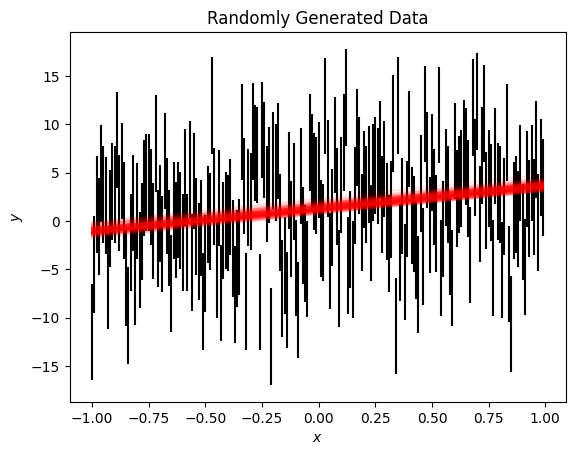

In [9]:
model = Polynomial('x', order=1, priors=[(2.3459, 0.1)]) + Constant()
model.fit(x=x, data=y, errors=ye)

fig, ax = plt.subplots()
ax.errorbar(x, y, ye, ls='', c='k')
ax.plot(x, np.asarray([model.sample(x=x) for count in range(100)]).T, c='r', alpha=0.1);
ax.set(xlabel='$x$', ylabel='$y$', title='Randomly Generated Data');

The posterior distribution of the model accounts for our priors

In [10]:
model.posteriors

DistributionContainer
	[(2.33, 0.099), (1.35, 0.35)]

Some models have more than one term. In that case you will need to supply priors for all terms. If you do not have priors for every term you can input "infinite" priors using a tuple or `Distribution`

In [11]:
(0, np.inf)

(0, inf)

which sets the mean to 0 and the standard deviation to infinity.